In [24]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.collections import PatchCollection
import matplotlib.patches as patches
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

In [2]:
# df=pd.read_pickle("class_var.pkl")

In [3]:
# # 去除重复列
# df = df.loc[:, ~df.columns.duplicated()]
# 
# # 定义高度替换规则
# def replace_level(row):
#     if row['place'] == 'ZS':
#         return '3 m' if row['level'] == 1 else f"{row['level']}m"
#     elif row['place'] == 'JH':
#         return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
#     elif row['place'] == 'CM':
#         return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
#     return f"{row['level']}m"
# 
# # 替换 level 列的值
# df['level'] = df.apply(replace_level, axis=1)

In [4]:
# # 将 'confidence' 列的值转为数值类型，并处理空值
# for i in range(1, 6):
#     df[f'confidence_{i}'] = pd.to_numeric(df[f'confidence_{i}'], errors='coerce').fillna(0)
# for i in range(1, 11):
#     df[f'confidence_voice_{i}'] = pd.to_numeric(df[f'confidence_voice_{i}'], errors='coerce').fillna(0)

In [5]:
# def get_top_n_birds(group, n=2, confidence_threshold=0.3):
#     # 提取 ['Date', 'place', 'level'] 信息
#     date_place_level = group[['Date', 'place', 'level']].iloc[0]
#     
#     birds_confidences = []
#     for i in range(1, 6):
#         bird = group[f'bird_{i}'].iloc[0]
#         confidence = group[f'confidence_{i}'].iloc[0]
#         if pd.notna(bird) and confidence >= confidence_threshold:
#             birds_confidences.append((bird, confidence))
#     
#     birds_confidences = sorted(birds_confidences, key=lambda x: x[1], reverse=True)[:n]
#     top_birds = pd.DataFrame({'Date': date_place_level['Date'],
#                               'place': date_place_level['place'],
#                               'level': date_place_level['level'],
#                               'bird': [b[0] for b in birds_confidences]})
#     return top_birds
# 
# # 处理鸟类数据
# grouped_birds = df.groupby(['Date', 'place', 'level']).apply(lambda group: get_top_n_birds(group)).reset_index(drop=True)

In [6]:
# def get_top_n_classes(group, n=5, confidence_threshold=0.3):
#     # 提取 ['Date', 'place', 'level'] 信息
#     date_place_level = group[['Date', 'place', 'level']].iloc[0]
#     
#     classes_confidences = []
#     for i in range(1, 11):
#         cls = group[f'class_{i}'].iloc[0]
#         confidence = group[f'confidence_voice_{i}'].iloc[0]
#         if pd.notna(cls) and confidence >= confidence_threshold:
#             classes_confidences.append((cls, confidence))
#     
#     classes_confidences = sorted(classes_confidences, key=lambda x: x[1], reverse=True)[:n]
#     top_classes = pd.DataFrame({'Date': date_place_level['Date'],
#                                 'place': date_place_level['place'],
#                                 'level': date_place_level['level'],
#                                 'class': [c[0] for c in classes_confidences]})
#     return top_classes
# 
# # 处理类别数据
# grouped_classes = df.groupby(['Date', 'place', 'level']).apply(lambda group: get_top_n_classes(group)).reset_index(drop=True)

In [7]:
# # 保存最终的 bird 数据表为 pkl 文件
# grouped_birds.to_pickle('grouped_birds.pkl')
# # 保存最终的 class 数据表为 pkl 文件
# grouped_classes.to_pickle('grouped_classes.pkl')

In [8]:
# # 读取数据表
# grouped_classes = pd.read_pickle('grouped_classes.pkl')
# grouped_birds = pd.read_pickle('grouped_birds.pkl')

In [9]:
# # 计算每种 bird 的频率
# bird_counts = grouped_birds['bird'].value_counts(normalize=True)
# filtered_birds = grouped_birds[grouped_birds['bird'].isin(bird_counts[bird_counts >= 0.01].index)]

In [10]:
# # 计算每种 class 的频率
# class_counts = grouped_classes['class'].value_counts(normalize=True)
# filtered_classes = grouped_classes[grouped_classes['class'].isin(class_counts[class_counts >= 0.01].index)]

In [11]:
# # 最终的 bird 数据表
# final_birds_df = filtered_birds[['Date', 'place', 'level', 'bird']]

In [12]:
# # 最终的 class 数据表
# final_classes_df = filtered_classes[['Date', 'place', 'level', 'class']]

In [13]:
# # 保存最终的 bird 数据表为 pkl 文件
# final_birds_df.to_pickle('final_birds_df.pkl')

In [14]:
# # 保存最终的 class 数据表为 pkl 文件
# final_classes_df.to_pickle('final_classes_df.pkl')

In [15]:
# 读取最终的 bird 数据表
final_birds_df = pd.read_pickle('final_birds_df.pkl')
# 读取最终的 class 数据表
final_classes_df = pd.read_pickle('final_classes_df.pkl')

In [16]:
df=final_birds_df.copy()

In [17]:
from palettable.tableau import GreenOrange_12
from palettable.lightbartlein.sequential import Blues7_2
from legendkit import colorart
from legendkit import cat_legend, vstack

In [18]:
def plotmonth(df,place):
    if place=='ALL':
        df=df
    else:
        df=df[df["place"]==place]
    def get_season(month):
        if month in (12, 1, 2):
            return 'Winter'
        elif month in (3, 4, 5):
            return 'Spring'
        elif month in (6, 7, 8):
            return 'Summer'
        elif month in (9, 10, 11):
            return 'Autumn'
    
    df['Month'] = df['Date'].dt.month
    month_order = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    df['Season'] = df['Month'].apply(get_season)
    df = df.sort_values('Month')
    month_labels = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df['Monthtext'] = df['Month'].map(month_labels)
    month_order = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    df['Monthtext'] = pd.Categorical(df['Monthtext'], categories=month_order, ordered=True)
    df = df.sort_values('Monthtext')
    # 计数每个Dominant_Key在每个时间段的出现次数
    df_grouped = df.copy().groupby(['Monthtext', 'bird'], observed=False).size().unstack(fill_value=0)
    # 转换数据以适应图形显示
    df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列
    #计算每个 Dominant_Key 的总出现次数
    df_pivot['Total'] = df_pivot.sum(axis=1)
    # 根据总量进行排序
    df_pivot = df_pivot.sort_values(by='Total', ascending=False)
    # 删除 'Total' 列，因为它不需要在绘图中展示
    df_pivot = df_pivot.drop(columns='Total')
    
    # 计算每个 bird 类别在不同 Monthtext 和 level 下的出现次数
    level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)
    # 计算每个组合的总数
    total_counts = level_counts.sum(axis=1)
    # 计算每个 level 的占比
    level_percentage = level_counts.div(total_counts, axis=0)
    
    
    def heatmap_with_circles(data_array, row_labels, column_labels, level_data, ax=None, cmap=Blues7_2.mpl_colormap):
        if ax is None:
            ax = plt.gca()
            
        # 计算所有 level 在整个 level_data 中的总量，并进行排序
        level_totals = level_data.sum().sort_values(ascending=False)
        sorted_levels = level_totals.index.tolist()
    
        # 为每个 level 分配颜色
        level_colors = {level: color for level, color in zip(sorted_levels, GreenOrange_12.mpl_colors)}
    
    
        # 创建heatmap
        c = ax.imshow(data_array, cmap=cmap, aspect='auto')
    
        # 在每个单元格中绘制饼图表示 level 的占比
        for (i, j), val in np.ndenumerate(data_array):
            levels = level_data.loc[(column_labels[j], row_labels[i])]
            if levels.sum() > 0:  # 确保总数大于0
                colors = [level_colors[level] for level in levels.index]
                wedges, _ = ax.pie(levels, colors=colors, radius=0.4, center=(j, i))
                for w in wedges:
                    w.set_center((j, i))
                    w.set_radius(0.4)  # 设置占比圆圈的大小
                    
    
        # 设置轴标签
        ax.set_xticks(np.arange(len(column_labels)))
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_xticklabels(column_labels, fontsize=10)
        ax.set_yticklabels(row_labels, fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
        # 设置网格线加粗
        ax.set_xticks(np.arange(data_array.shape[1]+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(data_array.shape[0]+1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)  # 去除minor tick marks
        ax.grid(which="major", linewidth=0)
        
        # 手动调整 spines 的宽度
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_linewidth(2)  # 设置边界线的宽度与网格线一致
            
        # 适当调整绘图区域的边界以避免网格线超出
        ax.set_xlim(-0.5, data_array.shape[1] - 0.5)
        ax.set_ylim(data_array.shape[0] - 0.5, -0.5)
        
        legend1=colorart(c, ax=ax,title='Counts',cmap=cmap)
        # 使用 legendkit 创建图例
        legend_args = dict(
            colors=[level_colors[level] for level in sorted_levels],
            labels=sorted_levels,
        )
        legend2 = cat_legend(**legend_args, title='Levels')
        vstack([legend1,legend2], title="", loc="out right center", spacing=10, frameon=False, ax=ax)
    
    # 模拟不同level的数据
    level_data = level_percentage
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_with_circles(df_pivot.values, df_pivot.index.tolist(), df_pivot.columns.tolist(), level_data, ax=ax)
    
    seasons = {
        'Winter': ['Dec', 'Jan', 'Feb'],
        'Spring': ['Mar', 'Apr', 'May'],
        'Summer': ['Jun', 'Jul', 'Aug'],
        'Autumn': ['Sep', 'Oct', 'Nov']
    }
    
    # 在图表中添加季节方块
    season_colors = {
        'Winter': '#2B7E7E',
        'Spring': '#39A939',
        'Summer': '#D38647',
        'Autumn': '#D34747'
    }
    
    # 在图表顶部添加季节的矩形背景和名称
    for season, months in seasons.items():
        start_idx = df_pivot.columns.get_loc(months[0])
        end_idx = df_pivot.columns.get_loc(months[-1])
        
        # 绘制矩形框
        ax.add_patch(
            patches.Rectangle(
                (start_idx-0.5 , 1),  # 矩形的 (x, y) 位置
                end_idx - start_idx + 1,   # 矩形的宽度
                0.04,  # 矩形的高度
                color=season_colors[season],
                alpha=0.3,
                transform=ax.get_xaxis_transform(),  # 位置相对于 x 轴
                clip_on=False
            )
        )
        
        # 在矩形背景上方添加季节名称
        ax.text(
            (start_idx + end_idx) / 2, 1.02,
            season,
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='black',
            transform=ax.get_xaxis_transform(), clip_on=False
        )
    
    
    # plt.tight_layout()
    plt.savefig(place+'物种月份变化.svg', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(place+'物种月份变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
    plt.show()

In [19]:
def plotmonth(df,place):
    if place=='ALL':
        df=df
    else:
        df=df[df["place"]==place]
    def get_season(month):
        if month in (12, 1, 2):
            return 'Winter'
        elif month in (3, 4, 5):
            return 'Spring'
        elif month in (6, 7, 8):
            return 'Summer'
        elif month in (9, 10, 11):
            return 'Autumn'
    
    df['Month'] = df['Date'].dt.month
    month_order = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    df['Season'] = df['Month'].apply(get_season)
    df = df.sort_values('Month')
    month_labels = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df['Monthtext'] = df['Month'].map(month_labels)
    month_order = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    df['Monthtext'] = pd.Categorical(df['Monthtext'], categories=month_order, ordered=True)
    df = df.sort_values('Monthtext')
    # 计数每个Dominant_Key在每个时间段的出现次数
    df_grouped = df.copy().groupby(['Monthtext', 'bird'], observed=False).size().unstack(fill_value=0)
    # 转换数据以适应图形显示
    df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列
    #计算每个 Dominant_Key 的总出现次数
    df_pivot['Total'] = df_pivot.sum(axis=1)
    # 根据总量进行排序
    df_pivot = df_pivot.sort_values(by='Total', ascending=False)
    # 删除 'Total' 列，因为它不需要在绘图中展示
    df_pivot = df_pivot.drop(columns='Total')
    
    # 计算每个 bird 类别在不同 Monthtext 和 level 下的出现次数
    level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)
    # 计算每个组合的总数
    total_counts = level_counts.sum(axis=1)
    # 计算每个 level 的占比
    level_percentage = level_counts.div(total_counts, axis=0)
    
    
    def heatmap_with_circles(data_array, row_labels, column_labels, level_data, ax=None, cmap=Blues7_2.mpl_colormap):
        if ax is None:
            ax = plt.gca()
            
        # 计算所有 level 在整个 level_data 中的总量，并进行排序
        level_totals = level_data.sum().sort_values(ascending=False)
        sorted_levels = level_totals.index.tolist()
    
        # 为每个 level 分配颜色
        level_colors = {level: color for level, color in zip(sorted_levels, GreenOrange_12.mpl_colors)}
    
    
        # 创建heatmap
        c = ax.imshow(data_array, cmap=cmap, aspect='auto')
    
        # 在每个单元格中绘制饼图表示 level 的占比
        for (i, j), val in np.ndenumerate(data_array):
            levels = level_data.loc[(column_labels[j], row_labels[i])]
            if levels.sum() > 0:  # 确保总数大于0
                colors = [level_colors[level] for level in levels.index]
                wedges, _ = ax.pie(levels, colors=colors, radius=0.4, center=(j, i))
                for w in wedges:
                    w.set_center((j, i))
                    w.set_radius(0.4)  # 设置占比圆圈的大小
                    
    
        # 设置轴标签
        ax.set_xticks(np.arange(len(column_labels)))
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_xticklabels(column_labels, fontsize=10)
        ax.set_yticklabels(row_labels, fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
        # 设置网格线加粗
        ax.set_xticks(np.arange(data_array.shape[1]+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(data_array.shape[0]+1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)  # 去除minor tick marks
        ax.grid(which="major", linewidth=0)
        
        # 手动调整 spines 的宽度
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_linewidth(2)  # 设置边界线的宽度与网格线一致
            
        # 适当调整绘图区域的边界以避免网格线超出
        ax.set_xlim(-0.5, data_array.shape[1] - 0.5)
        ax.set_ylim(data_array.shape[0] - 0.5, -0.5)
        
        legend1=colorart(c, ax=ax,title='Counts',cmap=cmap)
        # 使用 legendkit 创建图例
        legend_args = dict(
            colors=[level_colors[level] for level in sorted_levels],
            labels=sorted_levels,
        )
        legend2 = cat_legend(**legend_args, title='Levels')
        vstack([legend1,legend2], title="", loc="out right center", spacing=10, frameon=False, ax=ax)
    
    # 模拟不同level的数据
    level_data = level_percentage
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_with_circles(df_pivot.values, df_pivot.index.tolist(), df_pivot.columns.tolist(), level_data, ax=ax)
    
    seasons = {
        'Winter': ['Dec', 'Jan', 'Feb'],
        'Spring': ['Mar', 'Apr', 'May'],
        'Summer': ['Jun', 'Jul', 'Aug'],
        'Autumn': ['Sep', 'Oct', 'Nov']
    }
    
    # 在图表中添加季节方块
    season_colors = {
        'Winter': '#2B7E7E',
        'Spring': '#39A939',
        'Summer': '#D38647',
        'Autumn': '#D34747'
    }
    
    # 在图表顶部添加季节的矩形背景和名称
    for season, months in seasons.items():
        start_idx = df_pivot.columns.get_loc(months[0])
        end_idx = df_pivot.columns.get_loc(months[-1])
        
        # 绘制矩形框
        ax.add_patch(
            patches.Rectangle(
                (start_idx-0.5 , 1),  # 矩形的 (x, y) 位置
                end_idx - start_idx + 1,   # 矩形的宽度
                0.04,  # 矩形的高度
                color=season_colors[season],
                alpha=0.3,
                transform=ax.get_xaxis_transform(),  # 位置相对于 x 轴
                clip_on=False
            )
        )
        
        # 在矩形背景上方添加季节名称
        ax.text(
            (start_idx + end_idx) / 2, 1.02,
            season,
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='black',
            transform=ax.get_xaxis_transform(), clip_on=False
        )
    
    
    # plt.tight_layout()
    plt.savefig(place+'物种月份变化.svg', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(place+'物种月份变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
    plt.show()

In [20]:
def plotday(df,place):
    if place=='ALL':
        df=df
    else:
        df=df[df["place"]==place]
        
    # 确保Date列是datetime类型，并向下舍入到最近的30分钟
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time_Block'] = df['Date'].dt.floor('60min').dt.strftime('%H:%M')  # 使用 '30min' 替代 '30T'
    df = df.sort_values('Time_Block')
    # 计数每个Dominant_Key在每个时间段的出现次数
    df_grouped = df.copy().groupby(['Time_Block', 'bird'], observed=False).size().unstack(fill_value=0)
    # 转换数据以适应图形显示
    df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列
    #计算每个 Dominant_Key 的总出现次数
    df_pivot['Total'] = df_pivot.sum(axis=1)
    # 根据总量进行排序
    df_pivot = df_pivot.sort_values(by='Total', ascending=False)
    # 删除 'Total' 列，因为它不需要在绘图中展示
    df_pivot = df_pivot.drop(columns='Total')
    
    # 计算每个 bird 类别在不同 Monthtext 和 level 下的出现次数
    level_counts = df.groupby(['Time_Block', 'bird', 'level']).size().unstack(fill_value=0)
    # 计算每个组合的总数
    total_counts = level_counts.sum(axis=1)
    # 计算每个 level 的占比
    level_percentage = level_counts.div(total_counts, axis=0)
    
    
    def heatmap_with_circles(data_array, row_labels, column_labels, level_data, ax=None, cmap=Blues7_2.mpl_colormap):
        if ax is None:
            ax = plt.gca()
            
        # 计算所有 level 在整个 level_data 中的总量，并进行排序
        level_totals = level_data.sum().sort_values(ascending=False)
        sorted_levels = level_totals.index.tolist()
    
        # 为每个 level 分配颜色
        level_colors = {level: color for level, color in zip(sorted_levels, GreenOrange_12.mpl_colors)}
    
    
        # 创建heatmap
        c = ax.imshow(data_array, cmap=cmap, aspect='auto')
    
         # 在每个单元格中绘制饼图表示 level 的占比
        for (i, j), val in np.ndenumerate(data_array):
            # 检查是否存在对应的 row_label 和 column_label
            if (column_labels[j], row_labels[i]) in level_data.index:
                levels = level_data.loc[(column_labels[j], row_labels[i])]
                if levels.sum() > 0:  # 确保总数大于0
                    colors = [level_colors[level] for level in levels.index]
                    wedges, _ = ax.pie(levels, colors=colors, radius=0.4, center=(j, i))
                    for w in wedges:
                        w.set_center((j, i))
                        w.set_radius(0.4)  # 设置占比圆圈的大小
            else:
                print(f"Warning: ({column_labels[j]}, {row_labels[i]}) not found in level_data.")
                    
    
        # 设置轴标签
        ax.set_xticks(np.arange(len(column_labels)))
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_xticklabels(column_labels, fontsize=10)
        ax.set_yticklabels(row_labels, fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
        # 设置网格线加粗
        ax.set_xticks(np.arange(data_array.shape[1]+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(data_array.shape[0]+1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)  # 去除minor tick marks
        ax.grid(which="major", linewidth=0)
        
        # 手动调整 spines 的宽度
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_linewidth(2)  # 设置边界线的宽度与网格线一致
            
        # 适当调整绘图区域的边界以避免网格线超出
        ax.set_xlim(-0.5, data_array.shape[1] - 0.5)
        ax.set_ylim(data_array.shape[0] - 0.5, -0.5)
        
        legend1=colorart(c, ax=ax,title='Counts',cmap=cmap)
        # 使用 legendkit 创建图例
        legend_args = dict(
            colors=[level_colors[level] for level in sorted_levels],
            labels=sorted_levels,
        )
        legend2 = cat_legend(**legend_args, title='Levels')
        vstack([legend1,legend2], title="", loc="out right center", spacing=10, frameon=False, ax=ax)
    
    # 模拟不同level的数据
    level_data = level_percentage
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_with_circles(df_pivot.values, df_pivot.index.tolist(), df_pivot.columns.tolist(), level_data, ax=ax)
    # plt.tight_layout()
    plt.savefig(place+'物种日变化.svg', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(place+'物种日变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
    plt.show()

C:\Users\aa271\AppData\Local\Temp\ipykernel_32584\271296469.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)


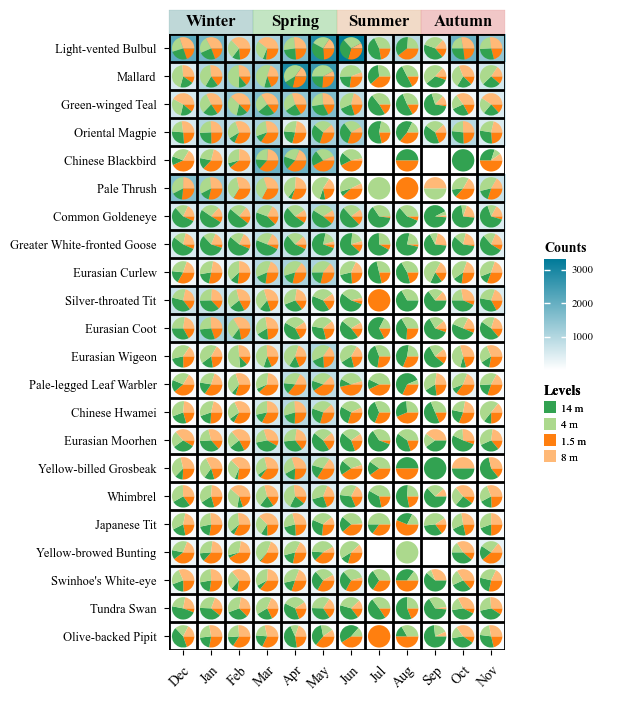

C:\Users\aa271\AppData\Local\Temp\ipykernel_32584\271296469.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)


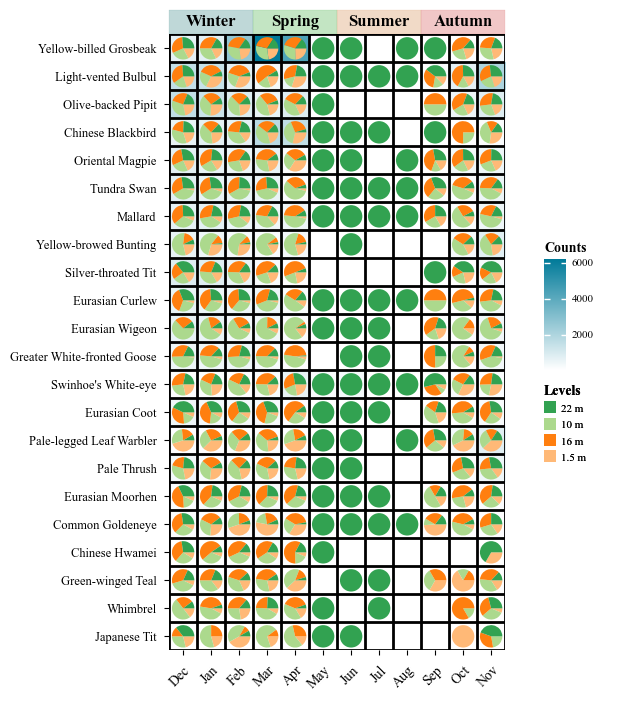

C:\Users\aa271\AppData\Local\Temp\ipykernel_32584\271296469.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)


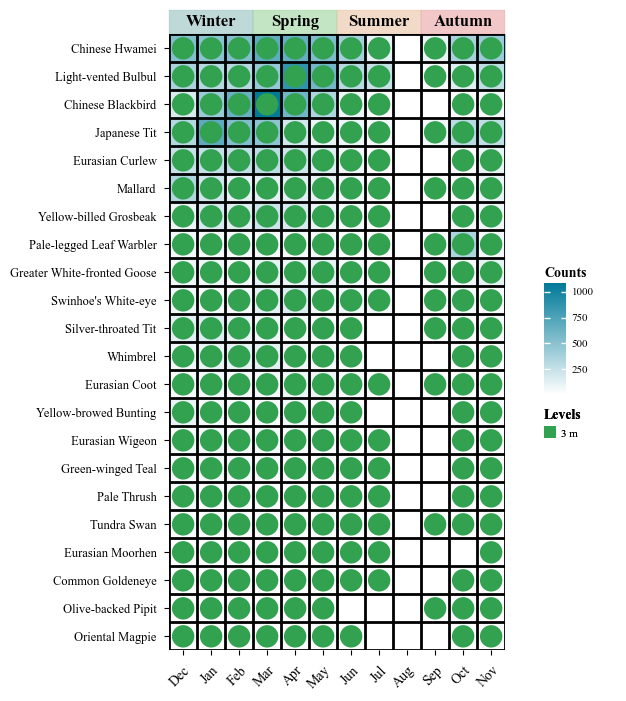

C:\Users\aa271\AppData\Local\Temp\ipykernel_32584\271296469.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_counts = df.groupby(['Monthtext', 'bird', 'level']).size().unstack(fill_value=0)


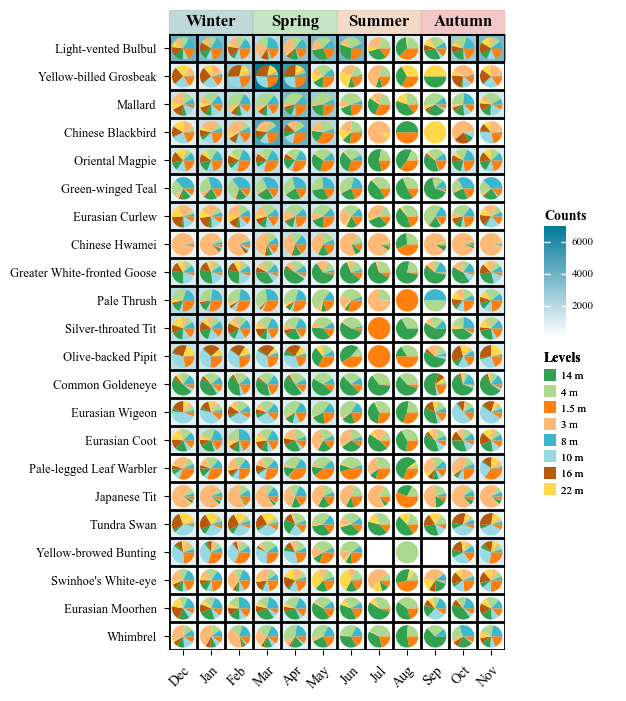

In [25]:
for i in ["JH",'CM','ZS','ALL']:
    plotmonth(final_birds_df.copy(),i)

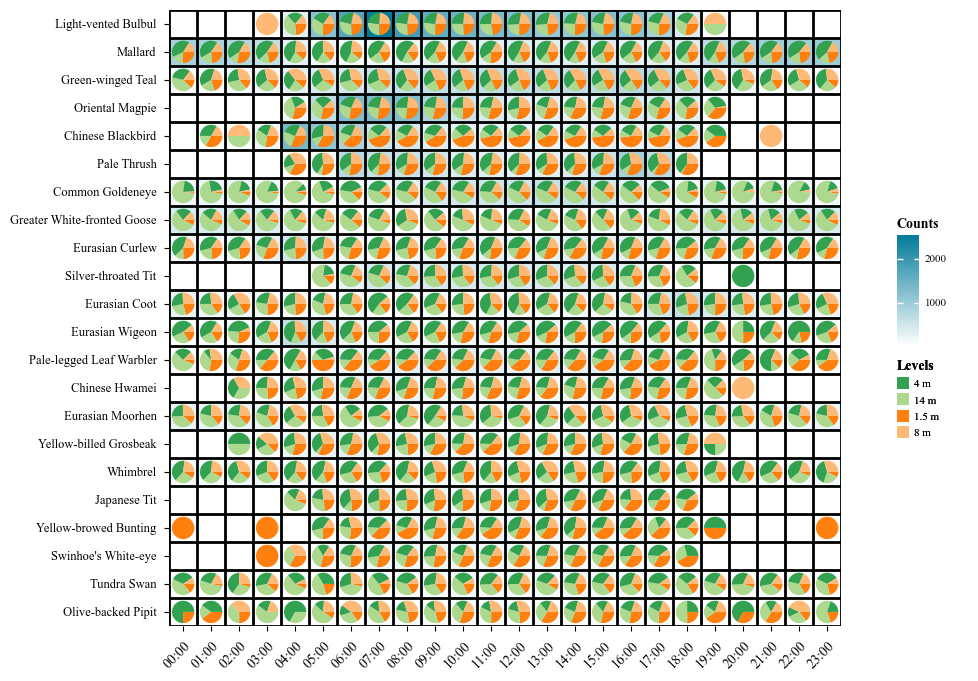

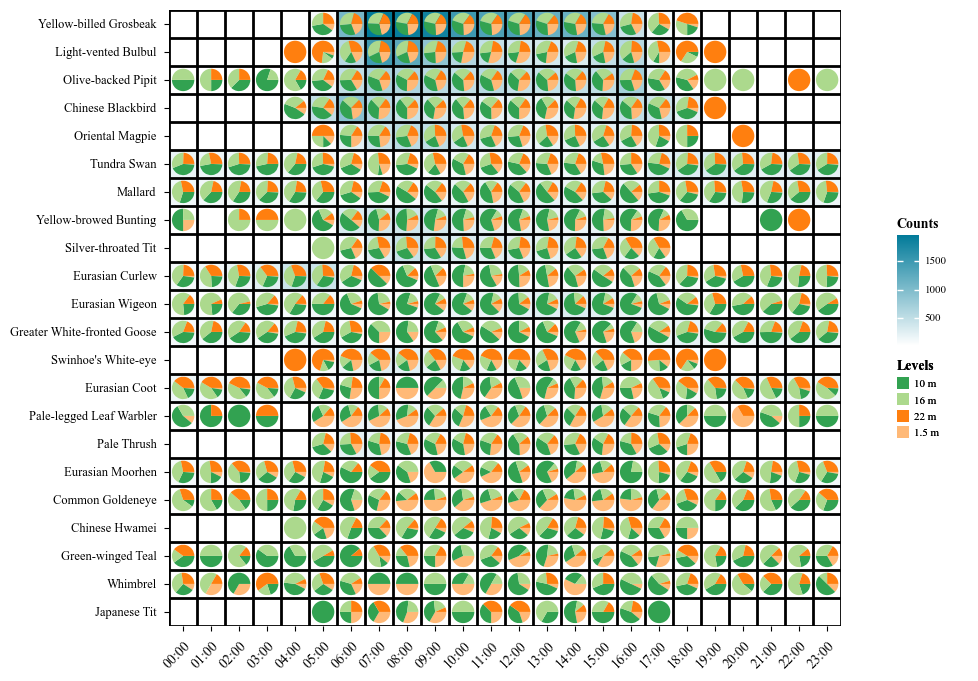

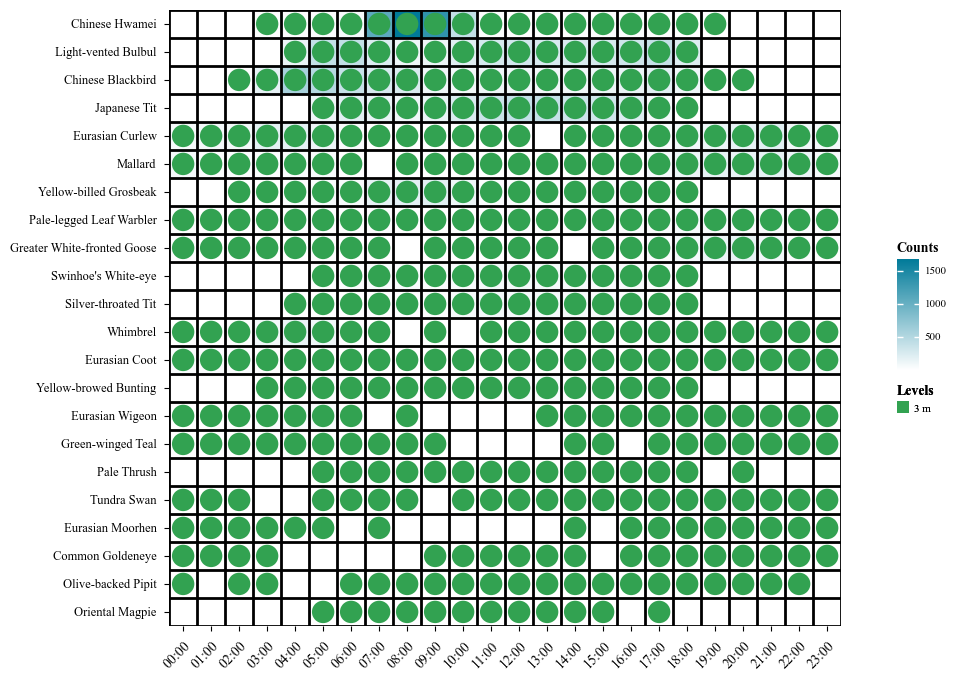

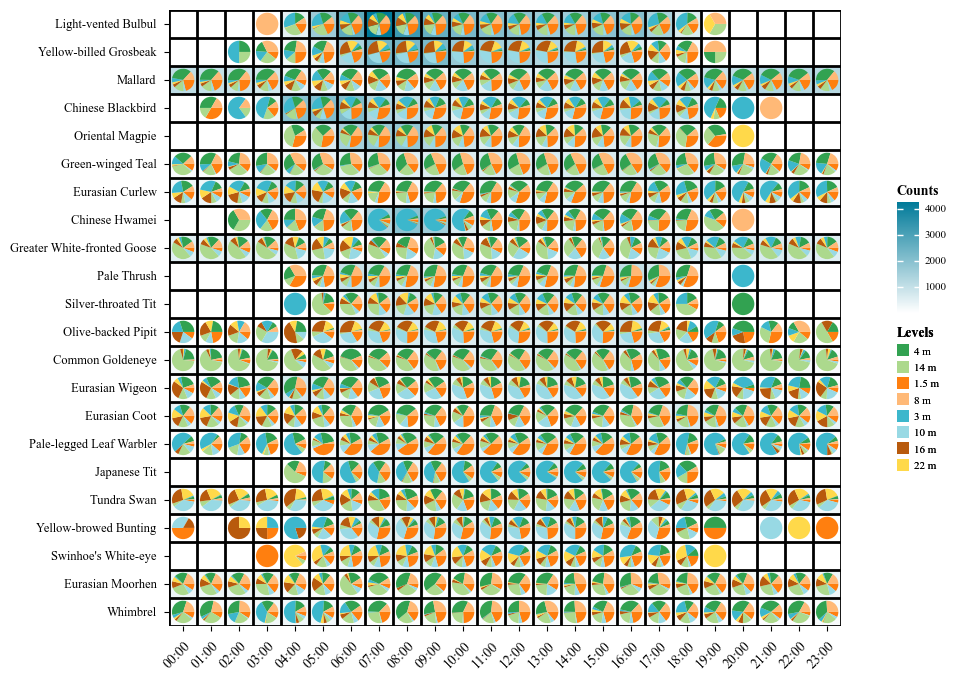

In [26]:
for i in ["JH",'CM','ZS','ALL']:
    plotday(final_birds_df.copy(),i)

In [27]:
def plotmonthclass(df,place):
    if place=='ALL':
        df=df
    else:
        df=df[df["place"]==place]
    def get_season(month):
        if month in (12, 1, 2):
            return 'Winter'
        elif month in (3, 4, 5):
            return 'Spring'
        elif month in (6, 7, 8):
            return 'Summer'
        elif month in (9, 10, 11):
            return 'Autumn'
    
    df['Month'] = df['Date'].dt.month
    month_order = [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    df['Season'] = df['Month'].apply(get_season)
    df = df.sort_values('Month')
    month_labels = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df['Monthtext'] = df['Month'].map(month_labels)
    month_order = ['Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
    df['Monthtext'] = pd.Categorical(df['Monthtext'], categories=month_order, ordered=True)
    df = df.sort_values('Monthtext')
    # 计数每个Dominant_Key在每个时间段的出现次数
    df_grouped = df.copy().groupby(['Monthtext', 'class'], observed=False).size().unstack(fill_value=0)
    # 转换数据以适应图形显示
    df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列
    #计算每个 Dominant_Key 的总出现次数
    df_pivot['Total'] = df_pivot.sum(axis=1)
    # 根据总量进行排序
    df_pivot = df_pivot.sort_values(by='Total', ascending=False)
    # 删除 'Total' 列，因为它不需要在绘图中展示
    df_pivot = df_pivot.drop(columns='Total')
    
    # 计算每个 bird 类别在不同 Monthtext 和 level 下的出现次数
    level_counts = df.groupby(['Monthtext', 'class', 'level']).size().unstack(fill_value=0)
    # 计算每个组合的总数
    total_counts = level_counts.sum(axis=1)
    # 计算每个 level 的占比
    level_percentage = level_counts.div(total_counts, axis=0)
    
    
    def heatmap_with_circles(data_array, row_labels, column_labels, level_data, ax=None, cmap=Blues7_2.mpl_colormap):
        if ax is None:
            ax = plt.gca()
            
        # 计算所有 level 在整个 level_data 中的总量，并进行排序
        level_totals = level_data.sum().sort_values(ascending=False)
        sorted_levels = level_totals.index.tolist()
    
        # 为每个 level 分配颜色
        level_colors = {level: color for level, color in zip(sorted_levels, GreenOrange_12.mpl_colors)}
    
    
        # 创建heatmap
        c = ax.imshow(data_array, cmap=cmap, aspect='auto')
    
        # 在每个单元格中绘制饼图表示 level 的占比
        for (i, j), val in np.ndenumerate(data_array):
            levels = level_data.loc[(column_labels[j], row_labels[i])]
            if levels.sum() > 0:  # 确保总数大于0
                colors = [level_colors[level] for level in levels.index]
                wedges, _ = ax.pie(levels, colors=colors, radius=0.4, center=(j, i))
                for w in wedges:
                    w.set_center((j, i))
                    w.set_radius(0.4)  # 设置占比圆圈的大小
                    
    
        # 设置轴标签
        ax.set_xticks(np.arange(len(column_labels)))
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_xticklabels(column_labels, fontsize=10)
        ax.set_yticklabels(row_labels, fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
        # 设置网格线加粗
        ax.set_xticks(np.arange(data_array.shape[1]+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(data_array.shape[0]+1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)  # 去除minor tick marks
        ax.grid(which="major", linewidth=0)
        
        # 手动调整 spines 的宽度
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_linewidth(2)  # 设置边界线的宽度与网格线一致
            
        # 适当调整绘图区域的边界以避免网格线超出
        ax.set_xlim(-0.5, data_array.shape[1] - 0.5)
        ax.set_ylim(data_array.shape[0] - 0.5, -0.5)
        
        legend1=colorart(c, ax=ax,title='Counts',cmap=cmap)
        # 使用 legendkit 创建图例
        legend_args = dict(
            colors=[level_colors[level] for level in sorted_levels],
            labels=sorted_levels,
        )
        legend2 = cat_legend(**legend_args, title='Levels')
        vstack([legend1,legend2], title="", loc="out right center", spacing=10, frameon=False, ax=ax)
    
    # 模拟不同level的数据
    level_data = level_percentage
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_with_circles(df_pivot.values, df_pivot.index.tolist(), df_pivot.columns.tolist(), level_data, ax=ax)
    
    seasons = {
        'Winter': ['Dec', 'Jan', 'Feb'],
        'Spring': ['Mar', 'Apr', 'May'],
        'Summer': ['Jun', 'Jul', 'Aug'],
        'Autumn': ['Sep', 'Oct', 'Nov']
    }
    
    # 在图表中添加季节方块
    season_colors = {
        'Winter': '#2B7E7E',
        'Spring': '#39A939',
        'Summer': '#D38647',
        'Autumn': '#D34747'
    }
    
    # 在图表顶部添加季节的矩形背景和名称
    for season, months in seasons.items():
        start_idx = df_pivot.columns.get_loc(months[0])
        end_idx = df_pivot.columns.get_loc(months[-1])
        
        # 绘制矩形框
        ax.add_patch(
            patches.Rectangle(
                (start_idx-0.5 , 1),  # 矩形的 (x, y) 位置
                end_idx - start_idx + 1,   # 矩形的宽度
                0.04,  # 矩形的高度
                color=season_colors[season],
                alpha=0.3,
                transform=ax.get_xaxis_transform(),  # 位置相对于 x 轴
                clip_on=False
            )
        )
        
        # 在矩形背景上方添加季节名称
        ax.text(
            (start_idx + end_idx) / 2, 1.02,
            season,
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='black',
            transform=ax.get_xaxis_transform(), clip_on=False
        )
    
    
    # plt.tight_layout()
    plt.savefig(place+'声音类别月份变化.svg', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(place+'声音类别月份变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
    plt.show()

In [28]:
def plotdayclass(df,place):
    if place=='ALL':
        df=df
    else:
        df=df[df["place"]==place]
        
    # 确保Date列是datetime类型，并向下舍入到最近的30分钟
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time_Block'] = df['Date'].dt.floor('60min').dt.strftime('%H:%M')  # 使用 '30min' 替代 '30T'
    df = df.sort_values('Time_Block')
    # 计数每个Dominant_Key在每个时间段的出现次数
    df_grouped = df.copy().groupby(['Time_Block', 'class'], observed=False).size().unstack(fill_value=0)
    # 转换数据以适应图形显示
    df_pivot = df_grouped.T  # 转置以使Dominant_Key为行，时间段为列
    #计算每个 Dominant_Key 的总出现次数
    df_pivot['Total'] = df_pivot.sum(axis=1)
    # 根据总量进行排序
    df_pivot = df_pivot.sort_values(by='Total', ascending=False)
    # 删除 'Total' 列，因为它不需要在绘图中展示
    df_pivot = df_pivot.drop(columns='Total')
    
    # 计算每个 bird 类别在不同 Monthtext 和 level 下的出现次数
    level_counts = df.groupby(['Time_Block', 'class', 'level']).size().unstack(fill_value=0)
    # 计算每个组合的总数
    total_counts = level_counts.sum(axis=1)
    # 计算每个 level 的占比
    level_percentage = level_counts.div(total_counts, axis=0)
    
    
    def heatmap_with_circles(data_array, row_labels, column_labels, level_data, ax=None, cmap=Blues7_2.mpl_colormap):
        if ax is None:
            ax = plt.gca()
            
        # 计算所有 level 在整个 level_data 中的总量，并进行排序
        level_totals = level_data.sum().sort_values(ascending=False)
        sorted_levels = level_totals.index.tolist()
    
        # 为每个 level 分配颜色
        level_colors = {level: color for level, color in zip(sorted_levels, GreenOrange_12.mpl_colors)}
    
    
        # 创建heatmap
        c = ax.imshow(data_array, cmap=cmap, aspect='auto')
    
         # 在每个单元格中绘制饼图表示 level 的占比
        for (i, j), val in np.ndenumerate(data_array):
            # 检查是否存在对应的 row_label 和 column_label
            if (column_labels[j], row_labels[i]) in level_data.index:
                levels = level_data.loc[(column_labels[j], row_labels[i])]
                if levels.sum() > 0:  # 确保总数大于0
                    colors = [level_colors[level] for level in levels.index]
                    wedges, _ = ax.pie(levels, colors=colors, radius=0.4, center=(j, i))
                    for w in wedges:
                        w.set_center((j, i))
                        w.set_radius(0.4)  # 设置占比圆圈的大小
            else:
                print(f"Warning: ({column_labels[j]}, {row_labels[i]}) not found in level_data.")
                    
    
        # 设置轴标签
        ax.set_xticks(np.arange(len(column_labels)))
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_xticklabels(column_labels, fontsize=10)
        ax.set_yticklabels(row_labels, fontsize=9)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
        # 设置网格线加粗
        ax.set_xticks(np.arange(data_array.shape[1]+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(data_array.shape[0]+1) - 0.5, minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", size=0)  # 去除minor tick marks
        ax.grid(which="major", linewidth=0)
        
        # 手动调整 spines 的宽度
        for spine in ['top', 'bottom', 'left', 'right']:
            ax.spines[spine].set_linewidth(2)  # 设置边界线的宽度与网格线一致
            
        # 适当调整绘图区域的边界以避免网格线超出
        ax.set_xlim(-0.5, data_array.shape[1] - 0.5)
        ax.set_ylim(data_array.shape[0] - 0.5, -0.5)
        
        legend1=colorart(c, ax=ax,title='Counts',cmap=cmap)
        # 使用 legendkit 创建图例
        legend_args = dict(
            colors=[level_colors[level] for level in sorted_levels],
            labels=sorted_levels,
        )
        legend2 = cat_legend(**legend_args, title='Levels')
        vstack([legend1,legend2], title="", loc="out right center", spacing=10, frameon=False, ax=ax)
    
    # 模拟不同level的数据
    level_data = level_percentage
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 8))
    heatmap_with_circles(df_pivot.values, df_pivot.index.tolist(), df_pivot.columns.tolist(), level_data, ax=ax)
    # plt.tight_layout()
    plt.savefig(place+'声音类别日变化.svg', bbox_inches='tight', pad_inches=0.1)
    plt.savefig(place+'声音类别日变化.png', bbox_inches='tight', pad_inches=0.1,dpi=500)
    plt.show()

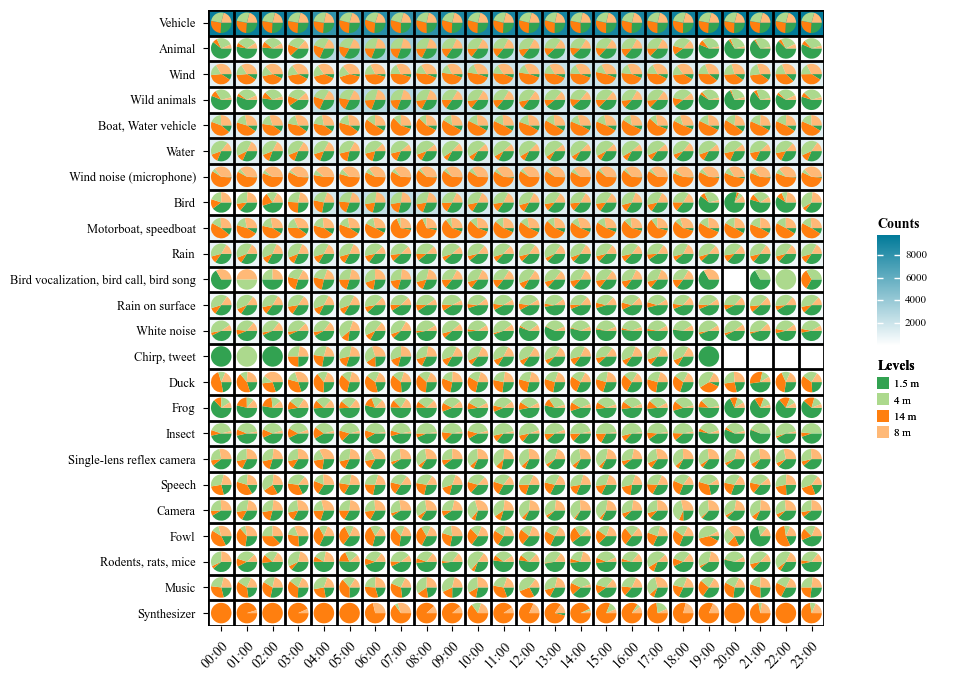

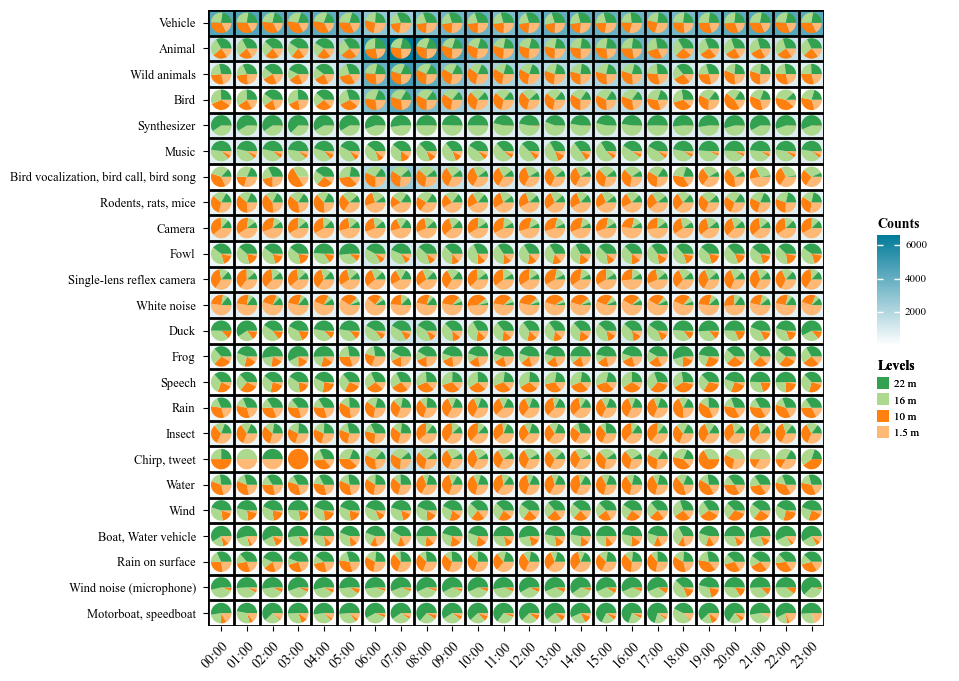

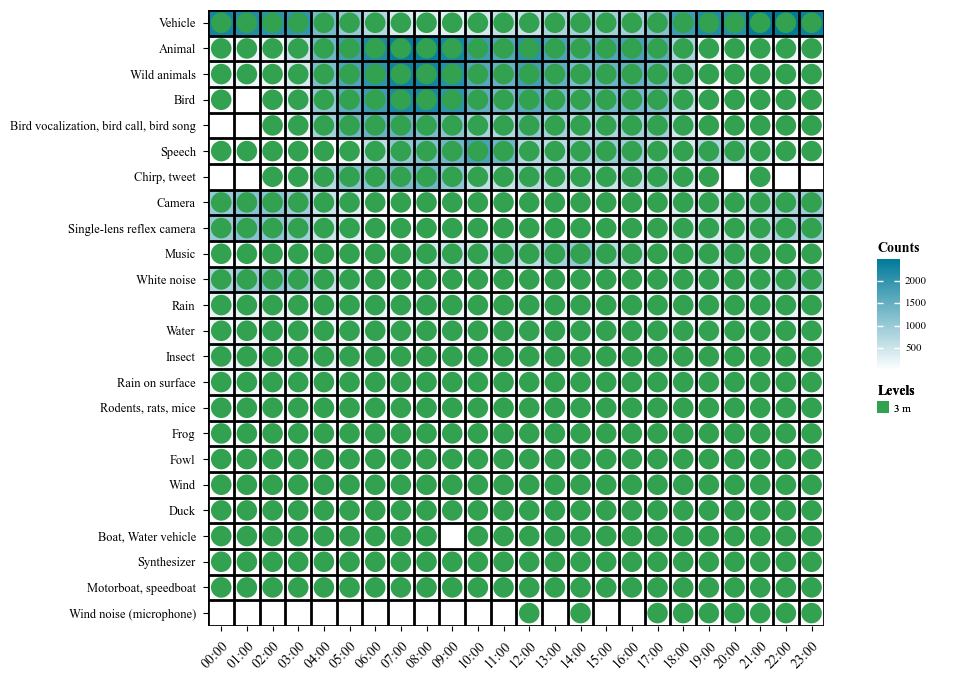

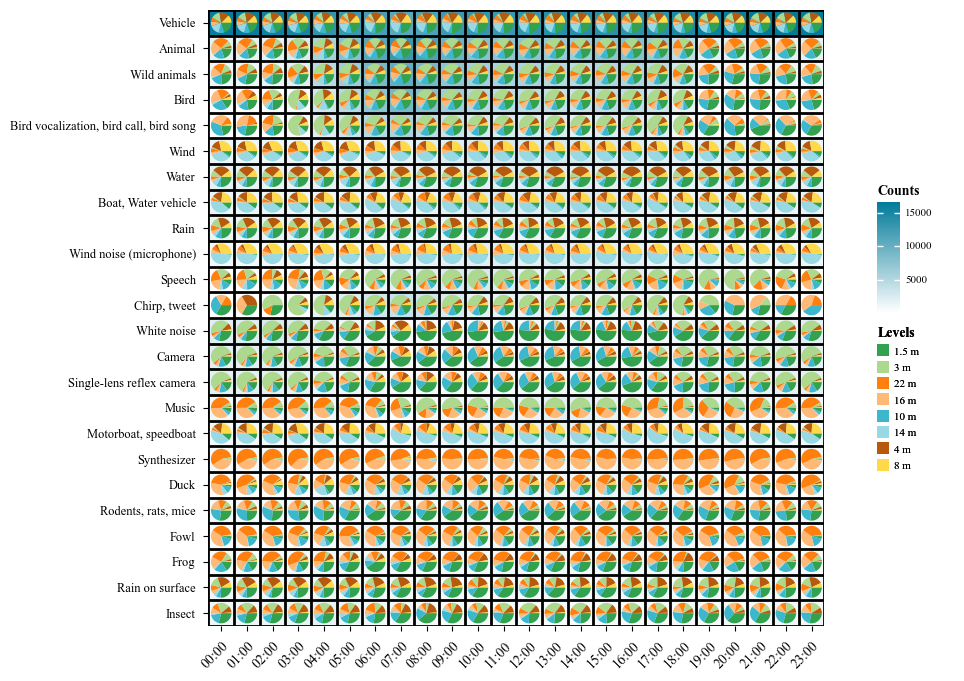

In [29]:
for i in ["JH",'CM','ZS','ALL']:
    plotdayclass(final_classes_df.copy(),i)